# OMG CTD Analysis
Emma Cameron, University of St Andrews

This notebook reproduces Figure 4 from the paper: "Greenland fjord processes have a depth-dependent influence on predicted submarine melt rates" submitted to Geophysical Research Letters.
  
Conservative temperature and absolute salinity data are displayed from two Greenland fjords in late summer 2016 by the Oceans Melting Greenland (OMG) project:

- Qarasaap Imaa (QIM)
- Kangerluluk (KLU)

The workflow:

1. Load CTD profiles from NetCDF files
2. Extract descent phase
3. Bin profiles in depth
4. Generate:
   - Temperature vs depth plots
   - Salinity vs depth plots
   - Temperature–Salinity (TS) diagrams
5. Combine into a 2×3 summary figure.

Data sources:
- OMG CTD NetCDF profiles (already converted to absolute salinity and conservative temperature using the TEOS-10 GSW library.)
- CSV files containing additional data such as fjord geometry and metadata.

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import netCDF4
import gsw
import matplotlib.patches as patches
from shapely.geometry import LineString, Polygon

In [2]:
# Define file paths from config file 
from config_loader import load_paths

# Load all base paths
paths = load_paths()

csv_dir = paths["csv_dir"]
nc_dir = paths["nc_dir"]
results_root = paths["results_dir"]

# Script-specific output folder for plots
output_dir = results_root / "caseStudies_qimKlu"
output_dir.mkdir(parents=True, exist_ok=True)

# Script-specific CSV file
qim_csv = csv_dir / "qimCTDs.csv"
klu_csv = csv_dir / "kluCTDs.csv"

## Set relative file paths from config file

In [3]:
# Plot styling 
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['axes.titlesize'] = 25
plt.rcParams['axes.labelsize'] = 20

We configure global matplotlib parameters to ensure all plots use consistent
font sizes legible at 100% zoom.

In [4]:
def isolate_descent_phase(depth, values):
    """Return only the downcast data"""
    deepest_idx = np.argmax(depth)
    return depth[:deepest_idx+1], values[:deepest_idx+1]


def load_nc_profile(nc_path):
    """Load depth, temperature and salinity from a NetCDF CTD file."""
    
    # squeeze to remove singleton dimensions
    with netCDF4.Dataset(nc_path) as ds:
        depth = np.squeeze(ds.variables["depth"][:]) 
        temp = np.squeeze(ds.variables["conservative_temperature"][:])
        sal = np.squeeze(ds.variables["absolute_salinity"][:])
    
    # Mask invalid values and fill with NaN
    depth = np.ma.masked_invalid(depth).filled(np.nan)
    temp = np.ma.masked_invalid(temp).filled(np.nan)
    sal = np.ma.masked_invalid(sal).filled(np.nan)

    return depth, temp, sal


def bin_profile(depth, values, bin_edges):
    """
    Bin profile data into fixed depth intervals.
    Returns bin centers and mean values.
    """

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    binned = np.full(len(bin_centers), np.nan)

    for i in range(len(bin_edges)-1):

        mask = (
            (depth >= bin_edges[i]) &
            (depth < bin_edges[i+1]) &
            np.isfinite(values)
        )

        if np.sum(mask) >= 3:
            binned[i] = np.nanmean(values[mask])

    return bin_centers, binned

## Utility Functions

These helper functions handle:

- extracting the descent phase of CTD profiles
- loading NetCDF variables
- binning profiles into fixed depth intervals

In [5]:
def load_fjord_2016(csv_path, nc_dir):

    df = pd.read_csv(csv_path)
    df["type"] = df["type"].str.lower()

    df = df[df["year"] == 2016]
    df = df[df["type"].isin(["mouth","middle","ng"])]

    profiles = {}

    bin_edges = np.arange(1,1001,10)

    for _, row in df.iterrows():

        nc_path = os.path.join(nc_dir, row["GSW_filename"])

        if not os.path.exists(nc_path):
            print(f"Missing file: {row['GSW_filename']}")
            continue

        depth, temp, sal = load_nc_profile(nc_path)

        depth, temp = isolate_descent_phase(depth, temp)
        _, sal = isolate_descent_phase(depth, sal)

        sal[(sal < 30) | (sal > 40)] = np.nan
        temp[np.isnan(sal)] = np.nan

        depth_bins, temp_binned = bin_profile(depth, temp, bin_edges)
        _, sal_binned = bin_profile(depth, sal, bin_edges)

        profiles[row["type"]] = {
            "depth": depth_bins,
            "temp": temp_binned,
            "sal": sal_binned
        }

    return profiles

## Load CTD Profiles

This function:

1. Reads CTD metadata from a CSV file
2. Loads NetCDF profiles
3. Filters unrealistic salinity values
4. Bins the profiles in 10 m depth intervals

In [6]:
# Define colors and labels for plotting
COLORS = {"mouth":"black","middle":"orange","ng":"red"}
LABELS = {"mouth":"Mouth","middle":"Mid-fjord","ng":"Near-glacier"}

# Plot temperature profiles with sill and grounding line depths
def plot_temp_depth(ax, profiles, fjord_row=None):
    for key in ["mouth","middle","ng"]:
        if key in profiles:
            p = profiles[key]
            ax.plot(p["temp"], p["depth"], color=COLORS[key], label=LABELS[key])
    
    # Add sill and grounding line depths
    ymin, ymax = ax.get_ylim()
    if fjord_row is not None:

        if 'sill_depth' in fjord_row and not np.isnan(fjord_row['sill_depth']):
            sill = fjord_row['sill_depth']
            
            if ymin <= sill <= ymax:   # only plot if visible  
                ax.axhline(sill, color='grey', linestyle='--', linewidth=1.5)

                ax.text(
                    0.01, sill+10,
                    'Sill depth',
                    transform=ax.get_yaxis_transform(),
                    fontsize=16,
                    color='grey',
                    ha='left',
                    va='top'
                )

        if 'grounding_line_depth' in fjord_row and not np.isnan(fjord_row['grounding_line_depth']):
            gl = fjord_row['grounding_line_depth']
            
            if ymin <= gl <= ymax:   # only plot if visible
                ax.axhline(gl, color='blue', linestyle='--', linewidth=1.5)

                ax.text(
                    0.01, gl+10,
                    'Grounding line',
                    transform=ax.get_yaxis_transform(),
                    color='blue',
                    fontsize=16,
                    ha='left',
                    va='top'
                )

    ax.set_xlim(-1,4.5)
    ax.set_ylim(1000,0)
    ax.set_xlabel("Conservative Temperature (°C)")
    ax.set_ylabel("Depth (m)")

# Plot temperature profiles 
Add sill depth and grounding line depth where available


In [7]:
# plot salinity profiles with sill and grounding line depths
def plot_sal_depth(ax, profiles, fjord_row=None):
    for key in ["mouth","middle","ng"]:
        if key in profiles:
            p = profiles[key]
            ax.plot(p["sal"], p["depth"], color=COLORS[key], label=LABELS[key])
    
    # Add sill and grounding line depths
     
    ymin, ymax = ax.get_ylim()
    if fjord_row is not None:

        if 'sill_depth' in fjord_row and not np.isnan(fjord_row['sill_depth']):
            sill = fjord_row['sill_depth']
            
            if ymin <= sill <= ymax:   # only plot if visible  
                ax.axhline(sill, color='grey', linestyle='--', linewidth=1.5)

                ax.text(
                    0.01, sill+10,
                    'Sill depth',
                    transform=ax.get_yaxis_transform(),
                    fontsize=16,
                    color='grey',
                    ha='left',
                    va='top'
                )

        if 'grounding_line_depth' in fjord_row and not np.isnan(fjord_row['grounding_line_depth']):
            gl = fjord_row['grounding_line_depth']
            
            if ymin <= gl <= ymax:   # only plot if visible
                ax.axhline(gl, color='blue', linestyle='--', linewidth=1.5)

                ax.text(
                    0.01, gl+10,
                    'Grounding line',
                    transform=ax.get_yaxis_transform(),
                    color='blue',
                    fontsize=16,
                    ha='left',
                    va='top'
                )

    
    ax.set_xlim(30,35)
    ax.set_ylim(1000,0)
    ax.set_xlabel("Absolute Salinity (g/kg)")
    ax.set_ylabel("Depth (m)")


# Plot salinity profiles

In [8]:
# TS diagram helper functions
def melt_temperature(S_melt):
    """Calculate the effective meltwater temperature"""
    L = 335000  # J/kg latent heat
    c_w = 3974  # J/kg/K seawater heat capacity
    c_i = 2009  # J/kg/K ice heat capacity
    T_i_C = -15
    T_i_K = T_i_C + 273.15
    # Ensure salinity is >= 0.001
    S_melt_safe = max(S_melt, 0.001)
    Theta_f_K = gsw.CT_freezing(S_melt_safe, p=0, saturation_fraction=0) + 273.15
    Theta_melt_K = Theta_f_K - (L / c_w) - (c_i / c_w) * (Theta_f_K - T_i_K)
    return Theta_melt_K - 273.15

def plot_gade_lines(ax, S_farfield_vals, Theta_farfield):
    for S_farfield in S_farfield_vals:
        S_melt = 0.0
        Theta_melt = melt_temperature(S_melt)
        S_gade = np.linspace(S_melt,S_farfield,100)
        m = (Theta_farfield-Theta_melt)/(S_farfield-S_melt)
        Theta_gade = Theta_melt + m*(S_gade-S_melt)
        ax.plot(S_gade, Theta_gade,'--',color='orange',alpha=0.5,lw=1)

def plot_freshwater_mixing_lines(ax, p_grounding, seawater_salinity=36, seawater_temps=[1,3,5,7,9,11]):
    # freezing temperature of fresh water at grounding line depth
    theta_subglacial = gsw.CT_freezing(0, p=p_grounding, saturation_fraction=0)
    
    S_sub = 0
    S_far = seawater_salinity
    
    for theta_far in seawater_temps:
        m = (theta_far - theta_subglacial) / (S_far - S_sub)
        S_arr = np.linspace(S_far, S_sub, 100)
        T_arr = theta_subglacial + m*(S_arr - S_sub)
        ax.plot(S_arr, T_arr, '--', color='blue', alpha=0.2, lw=1)


def add_water_mass_patches(ax, dsowContour):

    # AWm
    contour_path = dsowContour.collections[0].get_paths()[0]
    contour_vertices = contour_path.vertices

    # AWm rectangle limits 
    awm_box = Polygon([
        (34.56498220052732, 0.9807168639112821),
        (34.96690059820787, 0.9807168639112821),
        (34.96690059820787, 4.470413067475353),
        (34.56498220052732, 4.470413067475353),
    ])

    # Clip the box below contour
    clip_bottom = Polygon(
        list(contour_vertices) +
        [(35.5, -10), (29.5, -10)] +
        [(29.5, contour_vertices[0][1])]
    )

    awm_clipped = awm_box.intersection(clip_bottom)

    if not awm_clipped.is_empty:

        if awm_clipped.geom_type == 'Polygon':
            patch = patches.Polygon(
                list(awm_clipped.exterior.coords),
                facecolor='yellow',
                edgecolor='yellow',
                alpha=0.3,
                zorder=1
            )
            ax.add_patch(patch)

        elif awm_clipped.geom_type == 'MultiPolygon':
            for poly in awm_clipped:
                patch = patches.Polygon(
                    list(poly.exterior.coords),
                    facecolor='yellow',
                    edgecolor='yellow',
                    alpha=0.3,
                    zorder=1
                )
                ax.add_patch(patch)

    ax.text(
        34.77, 3, 'AWm',
        color='darkgrey',
        ha='center', va='center',
        fontsize=16,
        zorder=15
    )

    # PSW Labels

    ax.text(33.7, -0.3, 'PW',  color='darkgrey', ha='center', va='center', fontsize=16, zorder=10)
    ax.text(31.5, 2.5, 'PWw', color='darkgrey', ha='center', va='center', fontsize=16, zorder=10)

def add_depth_markers(ax, depths, salinity, temperature, color, marker_depths):
        if depths is None or salinity is None or temperature is None:
            return

        # Manual label offsets (in points)
        label_offsets = {
            30:  (0, -20),     # below
            130: (0, -20),   # below
            200: (-30, +7),    # left
            300: (-30, -4),    # left
            400: (-30, -4)     # left,
        }

        for d in marker_depths:
            idx = np.argmin(np.abs(depths - d))
            s = salinity[idx]
            t = temperature[idx]

            if np.isfinite(s) and np.isfinite(t):

                # Plot cross
                #ax.scatter(s, t, color=color, marker='x', s=150, zorder=10)
                ax.scatter(s, t, color=color, edgecolors='black', marker='o', s=80, zorder=10)

                # Get offset (default to upper-right if not specified)
                dx, dy = label_offsets.get(d, (6, 6))

                # Add label with manual offset
                ax.annotate(
                    f"{d} m",
                    (s, t),
                    textcoords="offset points",
                    xytext=(dx, dy),
                    ha='center',
                    fontsize=16,
                    color=color,
                    zorder=11
                )

def add_geometry_markers(ax, depths, salinity, temperature, fjord_row):

    if depths is None or salinity is None or temperature is None or fjord_row is None:
        return

    if 'sill_depth' in fjord_row and not np.isnan(fjord_row['sill_depth']):

        d_sill = fjord_row['sill_depth']
        idx = np.argmin(np.abs(depths - d_sill))

        s_sill = salinity[idx]
        t_sill = temperature[idx]

        if np.isfinite(s_sill) and np.isfinite(t_sill):
            ax.scatter(
                s_sill, t_sill,
                color='grey',
                marker='o',
                s=80,
                zorder=8,
                label='Sill depth'
            )

    if 'grounding_line_depth' in fjord_row and not np.isnan(fjord_row['grounding_line_depth']):

        d_gl = fjord_row['grounding_line_depth']
        idx = np.argmin(np.abs(depths - d_gl))

        s_gl = salinity[idx]
        t_gl = temperature[idx]

        if np.isfinite(s_gl) and np.isfinite(t_gl):
            ax.scatter(
                s_gl, t_gl,
                color='blue',
                marker='o',
                s=80,
                zorder=9,
                label='Grounding line'
            )

# TS diagram helper functions
These functions generate meltwater mixing lines, freshwater mixing lines, and label water masses on the TS diagram. They also create depth reference markers on the TS plot.

In [9]:
def plot_ts(ax, profiles, fjord_row=None, marker_depths=[30, 130, 200, 300, 400]):
    """
    TS diagram with:
      - Mouth / Mid-fjord / Near-glacier points
      - Depth crosses at standard depths
      - Gade lines
      - Freshwater mixing lines 
    """

    
    # --- Plot styling -----
    xmin, xmax = 30, 35
    ymin, ymax = -1, 4.5
    ax.set_xlabel('Absolute Salinity (g/kg)')
    ax.set_ylabel('Conservative Temperature (°C)')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(False)
    
    # Generate TS grid and sigma0
    S, T = np.meshgrid(
        np.linspace(xmin, xmax, 100),
        np.linspace(ymin, ymax, 100)
    )

    D = gsw.sigma0(S, T)

    levels = np.arange(np.floor(D.min()), np.ceil(D.max()) + 0.5, 0.5)

    CS = ax.contour(S, T, D, levels=levels, colors='black', linewidths=0.5, zorder=0)
    ax.clabel(CS, inline=True, fontsize=12, fmt="%.1f")

    dsowContour = ax.contour(S, T, D, levels=[27.8], colors='black', linewidths=1.5)
    ax.clabel(dsowContour, inline=True, fontsize=12, fmt='%1.1f')

    # Add water mass patches (AW, DSOW, AWm)    
    add_water_mass_patches(ax, dsowContour)    

    # --- Extract profiles ---
    ng = profiles.get("ng", {})
    mouth = profiles.get("mouth", {})
    middle = profiles.get("middle", {})
    
    ng_d, ng_t, ng_s = ng.get("depth"), ng.get("temp"), ng.get("sal")
    mouth_d, mouth_t, mouth_s = mouth.get("depth"), mouth.get("temp"), mouth.get("sal")
    mid_d, mid_t, mid_s = middle.get("depth"), middle.get("temp"), middle.get("sal")
    
    # --- Plot TS points ---
    if mouth_s is not None: ax.plot(mouth_s, mouth_t, 'ko', ms=5, label='Mouth')
    if mid_s is not None: ax.plot(mid_s, mid_t, 'o', color='orange', ms=5, label='Mid-fjord')
    if ng_s is not None: ax.plot(ng_s, ng_t, 'ro', ms=5, label='Near-glacier')
    
    #add depth markers
    add_depth_markers(ax, ng_d, ng_s, ng_t, 'red', marker_depths)

    # Add sill and grounding depth markers 
    add_geometry_markers(ax, ng_d, ng_s, ng_t, fjord_row)
    
    # --- Gade lines ---
    S_farfield_vals = np.arange(26, 40, 1)
    Theta_farfield = 10  # example farfield temp
    plot_gade_lines(ax, S_farfield_vals, Theta_farfield)
    
    # --- Freshwater mixing lines ---
    if fjord_row is not None:
        lat = fjord_row['latitude']
        depth_m = -fjord_row['grounding_line_depth']  # convert to negative for gsw
        p_ground = gsw.p_from_z(depth_m, lat)
        plot_freshwater_mixing_lines(ax, p_ground)
    
    # --- Final TS styling ---
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('Absolute Salinity (g/kg)', fontsize=20)
    ax.set_ylabel('Conservative Temperature (°C)', fontsize=20)
    ax.grid(False)
    ax.legend(loc='upper left')

# Plot TS diagram 
Includes depth markers, Gade lines, and freshwater mixing lines as well as water mass locations, and sill and grounding line depth markers.

In [10]:
def create_2x3_plot(qim_profiles, klu_profiles, qim_csv, klu_csv, output_dir):
    # Load CSVs for metadata
    qim_df = pd.read_csv(qim_csv)
    klu_df = pd.read_csv(klu_csv)
    qim_df["type"] = qim_df["type"].str.lower()
    klu_df["type"] = klu_df["type"].str.lower()
    
    fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10),
    sharex='col',
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1, 1.5]}  # TS column is 1.5× wider
    )

    plt.subplots_adjust(left=0.10)

    # ----- Top row: QIM -----
    fjord_meta = qim_df[qim_df["type"]=="ng"].iloc[0]
    plot_temp_depth(axes[0,0], qim_profiles, fjord_row=fjord_meta)
    plot_sal_depth(axes[0,1], qim_profiles, fjord_row=fjord_meta)
    
    # Pass fjord metadata to TS plot
    # Pick any row for metadata, e.g., "ng" type
    qim_meta = qim_df[qim_df["type"]=="ng"].iloc[0]
    plot_ts(axes[0,2], qim_profiles, fjord_row=qim_meta)

    # ----- Bottom row: KLU -----
    fjord_meta = klu_df[klu_df["type"]=="ng"].iloc[0]
    plot_temp_depth(axes[1,0], klu_profiles, fjord_row=fjord_meta)
    plot_sal_depth(axes[1,1], klu_profiles, fjord_row=fjord_meta)

    klu_meta = klu_df[klu_df["type"]=="ng"].iloc[0]
    plot_ts(axes[1,2], klu_profiles, fjord_row=klu_meta)

    # Labels
    for ax in axes.flatten():
        ax.set_xlabel(''); ax.set_ylabel('')
    axes[0,0].set_ylabel('Depth (m)'); axes[1,0].set_ylabel('Depth (m)')
    axes[0,2].set_ylabel('Conservative Temperature (°C)'); axes[1,2].set_ylabel('Conservative Temperature (°C)')
    axes[1,0].set_xlabel('Conservative Temp (°C)')
    axes[1,1].set_xlabel('Absolute Salinity (g/kg)')
    axes[1,2].set_xlabel('Absolute Salinity (g/kg)')

    # Axes where we want to filter out 'sill depth' and 'grounding line depth'
    axes_to_filter = [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]

    # Loop over all axes
    for i in range(2):         # rows
        for j in range(3):     # columns
            ax = axes[i,j]
            
            handles, labels = ax.get_legend_handles_labels()
            
            if ax in axes_to_filter:
                # Filter out unwanted labels
                filtered = [(h, l) for h, l in zip(handles, labels)
                            if 'sill depth' not in l.lower() and 'grounding line' not in l.lower()]
                
                if filtered:
                    filtered_handles, filtered_labels = zip(*filtered)
                    ax.legend(filtered_handles, filtered_labels, loc='lower left')
                else:
                    ax.legend([], [], loc='lower left')  # optional: blank legend
            else:
                # Keep all labels for axes not in filter list
                ax.legend(handles, labels, loc='lower left')

    # Row labels
    fig.text(-0.025, 0.75, "Qarasaap Imaa (2016)",
         fontsize=22,
         fontweight='bold',
         rotation=90,
         va='center')

    fig.text(-0.025, 0.28, "Kangerluluk (2016)",
         fontsize=22,
         fontweight='bold',
         rotation=90,
         va='center')
    
    # Label subfigure panels 
    panel_labels = ['a','b','c','d','e','f']
    axes_list = [axes[0,0], axes[0,1], axes[0,2],
                axes[1,0], axes[1,1], axes[1,2]]

    for ax, label in zip(axes_list, panel_labels):
        # x=-0.1 means left of the axes, y=1.05 means just above the axes
        ax.text(-0.2, 1.1, f'({label})', transform=ax.transAxes,
                fontsize=18, fontweight='bold', va='top', ha='left')
            
    # Save fig
    plot_filename = "qim_klu_combined.png"
    plt.savefig(os.path.join(output_dir, plot_filename), dpi=300, bbox_inches='tight')
    plt.show()

    plt.close(fig)

# Create 2x3 plot layout
Set the dimensions, font sizes, labels, and final layout. Save the figure.

C:\Users\efc4\AppData\Local\Temp\ipykernel_14916\3274171038.py:16: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.10)
C:\Users\efc4\AppData\Local\Temp\ipykernel_14916\107703012.py:41: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  contour_path = dsowContour.collections[0].get_paths()[0]


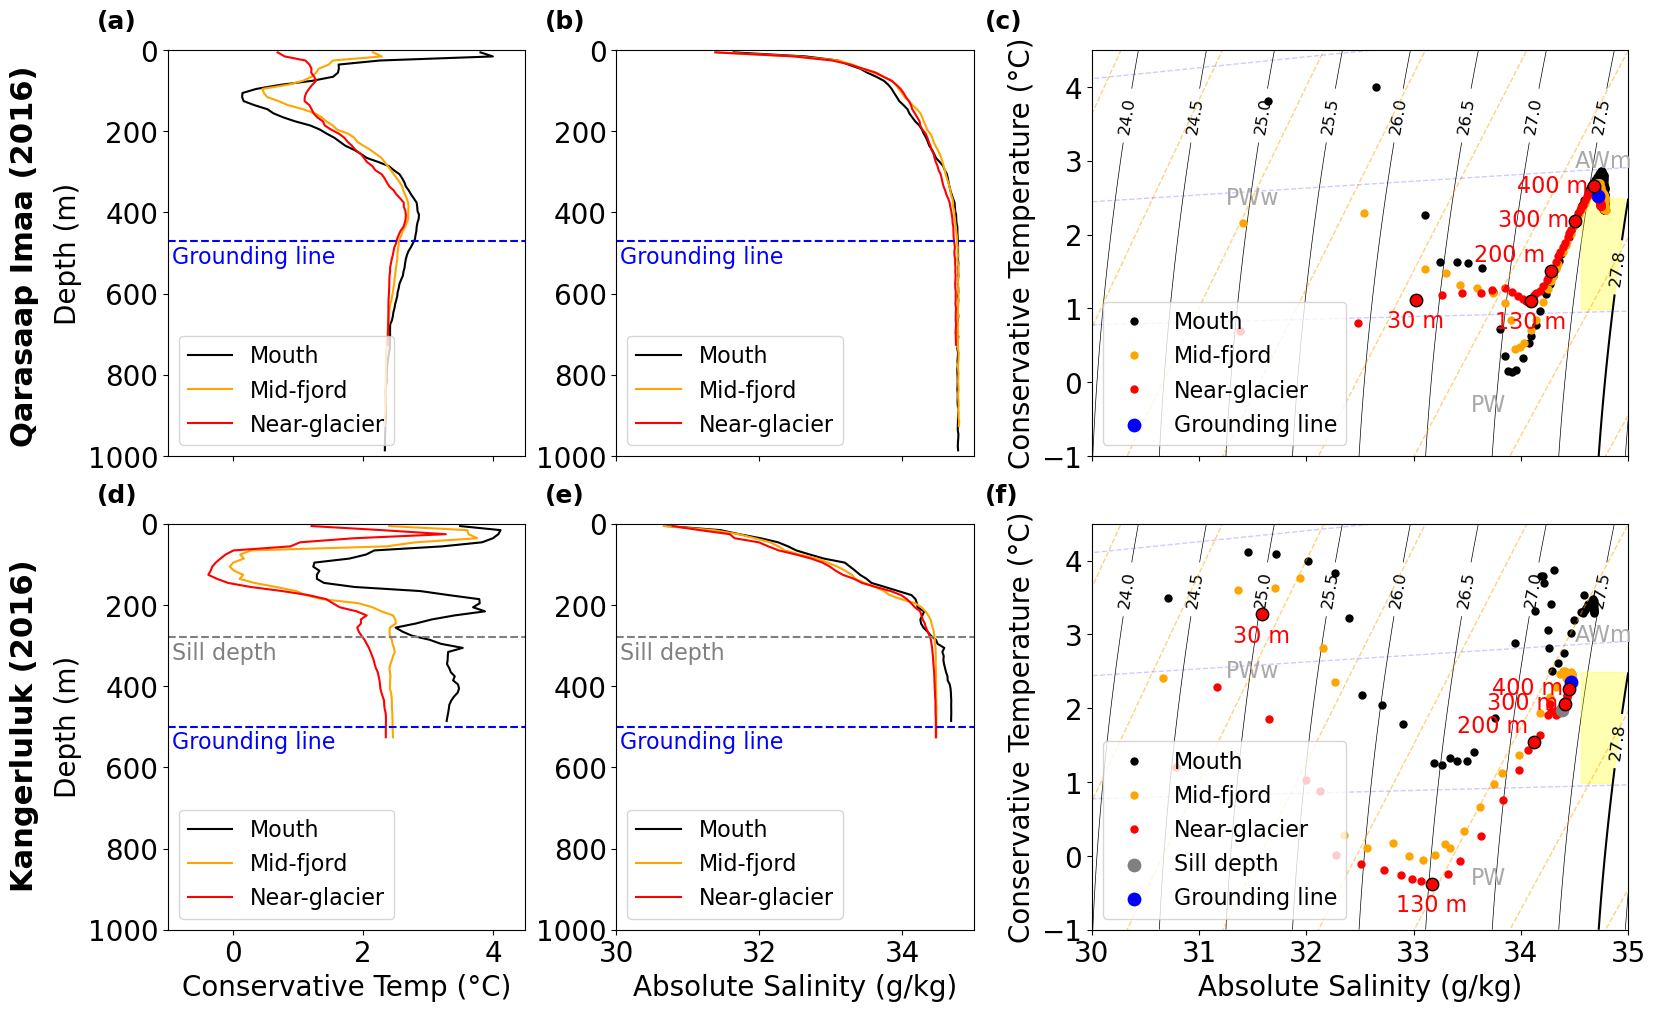

In [ ]:
# Run the code
if __name__ == "__main__":
   
    qim_profiles = load_fjord_2016(qim_csv,nc_dir)
    klu_profiles = load_fjord_2016(klu_csv,nc_dir)
    
    create_2x3_plot(qim_profiles, klu_profiles, qim_csv, klu_csv, output_dir)